[*********************100%***********************]  1 of 1 completed


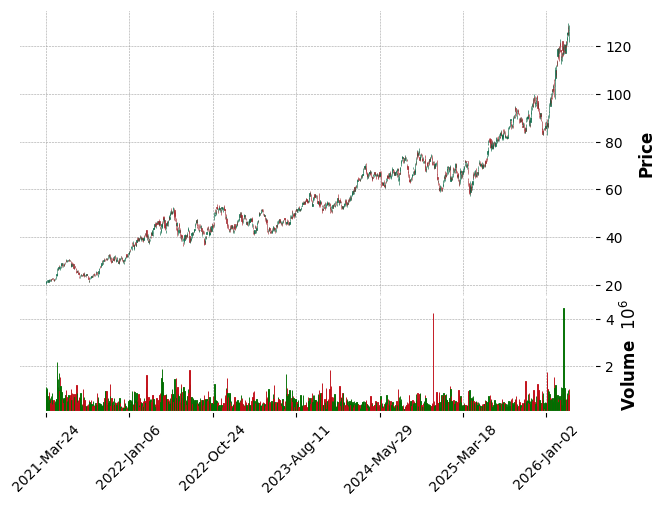

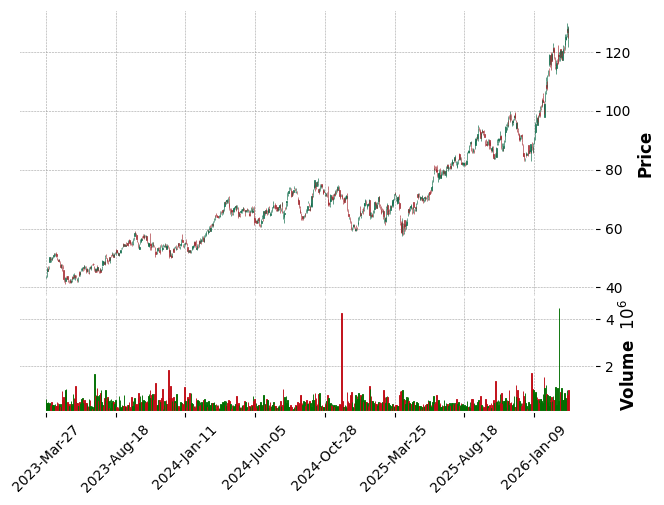

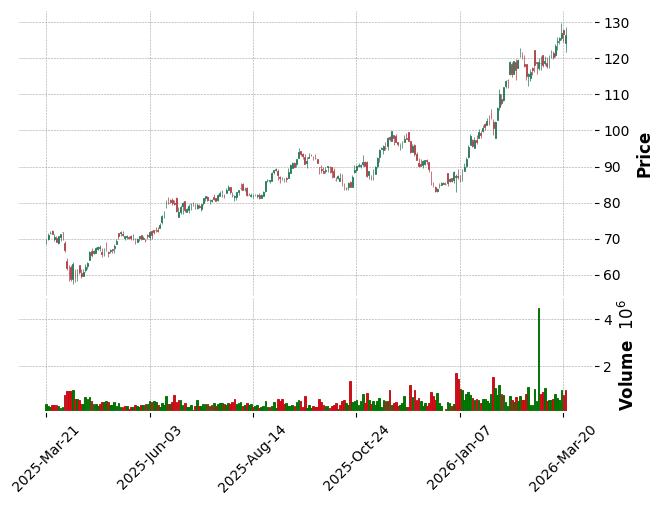

In [1]:
%load_ext autoreload
%autoreload 1
%aimport fundamentals

import finnhub
import pandas as pd
import json
from fundamentals import Fundamentals
import numpy as np
from itables import init_notebook_mode, options
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import mplfinance as mpf
import ipynbname
init_notebook_mode(all_interactive=True)
options.style = "table-layout:auto; width:50%;"
plt.style.use('dark_background')
pd.set_option('display.float_format', '{:.2f}'.format)

# Setup client
# ASIX
name = ipynbname.name().strip('.ipynb').upper()
thirtyday = dt.datetime.now() - dt.timedelta(days=90)
Fun = Fundamentals(name, thirtyday.strftime('%Y-%m-%d'), dt.datetime.now().strftime('%Y-%m-%d'))

historical = Fun.get_history()
historical.columns = historical.columns.get_level_values(0)
mpf.plot(historical, type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-750:], type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-252:], type='candle', style='charles',volume=True)

In [2]:
funds = Fun.get_fundamentals()

funds

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


126.52


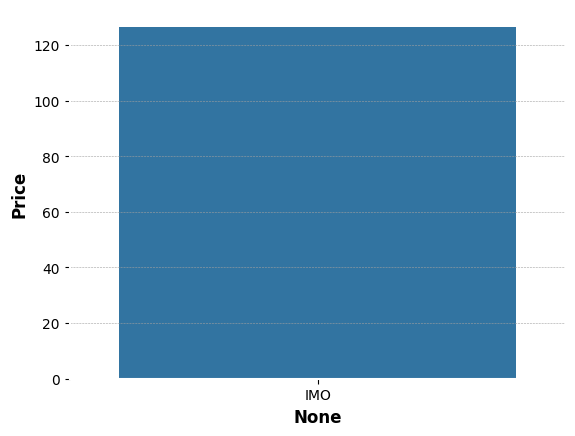

In [3]:
peers, avg_price = Fun.get_peers()
print(avg_price)
sns.barplot(x=peers.index, y=peers['Price'])
plt.show()

In [4]:
fairValues = Fun.caculateFairValues()

fairValues.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [5]:
other_metrics = Fun.get_other_metric()

other_metrics.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [6]:
insider_sentiment = Fun.get_insider_sentiment()
print(f"{insider_sentiment[0]}:")
print("")
print(insider_sentiment[1])

insider_signal:

Bullish (Net Buy): 1,572 shares


In [7]:
news = Fun.get_news()

for x in news:
    print(x['datetime'])
    print(x['headline'])
    print(x['summary'])
    print(x['url'])
    print("")

2026-03-23 02:13:55
Shares of oil-related companies are trading lower after President Trump announced in a Truth Social post the suspension of U.S. strikes on Iranian power generation and energy infrastructure for five days, subject to the outcome of ongoing discussions.

https://finnhub.io/api/news?id=6af06ccc3919bf63c2a484b2bbf9d2f9ab2413c467a9800b8812ac89aaf4e7d4

2026-03-12 03:00:00
What President Trump Says Vs. What The Mines In Iran Say
Analyzing geopolitical constraints over preferences provides alpha by focusing on world realities during the ongoing war situation. Read my analysis here.
https://finnhub.io/api/news?id=39af65f3fa0be64e3d1ba247020bc7aa805a9c0d378ec9be2e7e906cdf281b44

2026-03-10 07:07:03
Shares of oil-related companies are trading lower as oil prices retreat to under $90 per barrel after President Trump's comments about the conflict with Iran ending soon. Also, G7 governments will meet on Tuesday to discuss using strategic oil reserves.

https://finnhub.io/api/new

Average Weighted EPS: 0.8808
Lower Standard Deviation: 0.1243336520721986
Upper Standard Deviation: 1.6372663479278016
Total Debt/Total Equity: 0.1796


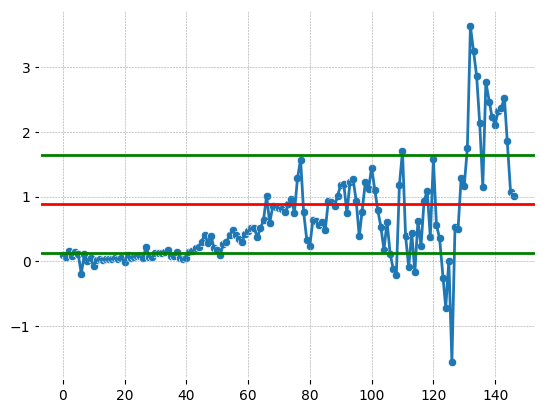

In [8]:
inflect = Fun.get_inflections()

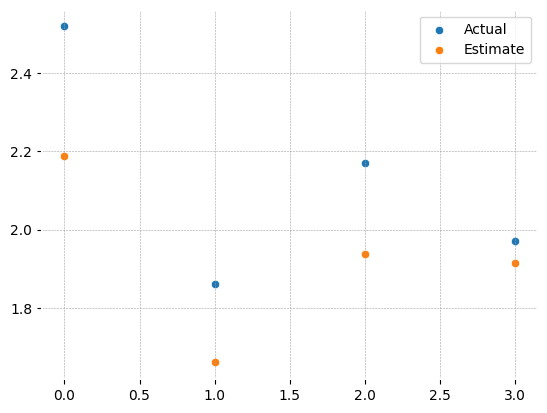

In [9]:
surprise = Fun.eps_surprise()

2025-12-31   45203000000.00
2024-12-31   48824000000.00
2023-12-31   48300000000.00
2022-12-31   57234000000.00
2021-12-31              NaN
Name: Total Revenue, dtype: float64
Revenue: [4.5203e+10 4.8824e+10 4.8300e+10 5.7234e+10        nan]


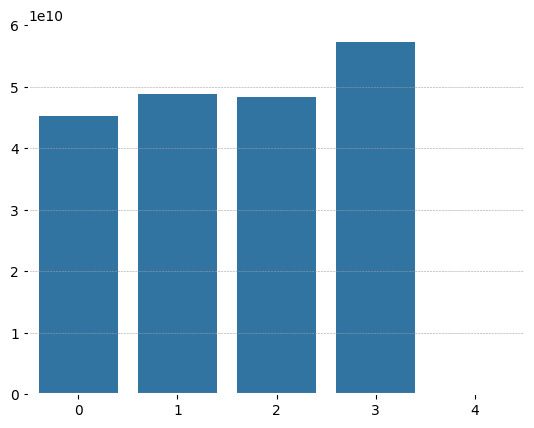

In [10]:
revenue = Fun.revenue_growth()